# Machine Learning Application

Let's start here! If you can directly link to an image relevant to your notebook, such as [canonical logos](https://github.com/numpy/numpy/blob/main/doc/source/_static/numpylogo.svg), do so here at the top of your notebook. You can do this with MyST Markdown syntax, outlined in [this MyST guide](https://mystmd.org/guide/figures), or you edit this cell to see a demonstration. **Be sure to include `alt` text for any embedded images to make your content more accessible.**

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

Next, title your notebook appropriately with a top-level Markdown header, `#` (see the very first cell above). Do not use this level header anywhere else in the notebook. Our book build process will use this title in the navbar, table of contents, etc. Keep it short, keep it descriptive. 

Follow this with a `---` cell to visually distinguish the transition to the prerequisites section.

---

## Overview
If you have an introductory paragraph, lead with it here! Keep it short and tied to your material, then be sure to continue into the required list of topics below,

1. This is a numbered list of the specific topics
1. These should map approximately to your main sections of content
1. Or each second-level, `##`, header in your notebook
1. Keep the size and scope of your notebook in check
1. And be sure to let the reader know up front the important concepts they'll be leaving with

## Prerequisites
This section was inspired by [this template](https://github.com/alan-turing-institute/the-turing-way/blob/master/book/templates/chapter-template/chapter-landing-page.md) of the wonderful [The Turing Way](https://the-turing-way.netlify.app) Jupyter Book.

Following your overview, tell your reader what concepts, packages, or other background information they'll **need** before learning your material. Tie this explicitly with links to other pages here in Foundations or to relevant external resources. Remove this body text, then populate the Markdown table, denoted in this cell with `|` vertical brackets, below, and fill out the information following. In this table, lay out prerequisite concepts by explicitly linking to other Foundations material or external resources, or describe generally helpful concepts.

Label the importance of each concept explicitly as **helpful/necessary**.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Project management | Helpful | |

- **Time to learn**: estimate in minutes. For a rough idea, use 5 mins per subsection, 10 if longer; add these up for a total. Safer to round up and overestimate.
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

---

## Imports
Begin your body of content with another `---` divider before continuing into this section, then remove this body text and populate the following code cell with all necessary Python imports **up-front**:

In [1]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
import xarray as xr
import pandas as pd
import dask
import s3fs

# Set Up

In [2]:
ANALYSIS_PERIOD = slice('1981-01-01', '2024-12-31')
TRAINING_PERIOD = slice('1981-01-01', '2010-12-31')
TESTING_PERIOD = slice('2011-01-01', '2024-12-31')
# test = slice('2022-01-01', '2024-12-31')
LEAD_TIME = 14 # Lead time between predictor and predictand
NAIROBI_COORDS = {"lat": -1.2921, "lon": 36.8219}


## Data Mangement

In [9]:
# from dask.distributed import Client, LocalCluster
# cluster = LocalCluster(
#     n_workers=5,
#     memory_limit='8GB',
# )

# client = cluster.get_client()
# client

### 2-Meter Temperature

In [4]:
# # Defines path of GDEX data source
# GDEX_URL = 'https://osdf-director.osg-htc.org/ncar/gdex/d633000/e5.oper.an.sfc.zarr/e5.oper.an.sfc.2t.zarr'
# t2m_hourly_ds = xr.open_dataset(GDEX_URL, engine='zarr')
# t2m_hourly_ds = t2m_hourly_ds.drop_vars({'quantization_info', 'utc_date'})
# t2m_hourly_ds = t2m_hourly_ds.sel(time=test)
# t2m_hourly_nairobi_ds = t2m_hourly_ds.sel(latitude=NAIROBI_COORDS['lat'], longitude=NAIROBI_COORDS['lon'], method='nearest')
# t2m_hourly_nairobi_ds

<xarray.Dataset> Size: 316kB
Dimensions:    (time: 26304)
Coordinates:
    latitude   float64 8B -1.25
    longitude  float64 8B 36.75
  * time       (time) datetime64[ns] 210kB 2022-01-01 ... 2024-12-31T23:00:00
Data variables:
    VAR_2T     (time) float32 105kB ...
Attributes:
    CONVERSION_DATE:      Mon 01 Sep 2025 04:08:47 PM MDT
    CONVERSION_PLATFORM:  Linux crhtc71 5.14.21-150400.24.46-default #1 SMP P...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    history:              Mon Sep  1 16:26:33 2025: ncks -4 -L 1 --baa=0 --pp...

In [6]:
# t2m_hourly_nairobi_ds.compute()

Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2026-06-17 20:14:35,644 - distributed.nanny - ERROR - Worker process died unexpectedly
2026-06-17 20:14:35,644 - distributed.nanny - ERROR - Worker process died unexpectedly
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.10/site-packages/distributed/nanny.py", line 998, in _run
    asyncio_run(run(), loop_factory=get_loop_factory())
  File "/srv/conda/envs/notebook/lib/python3.10/site-packages/distributed/compatibility.py", line 67, in asyncio_run
    return loop.run_until_complete(main)
  File "/srv/conda/envs/notebook/lib/python3.10/asyncio/base_events.py", line 636, in run_until_complete
    self.run_forever()
  File "/srv/conda/envs/notebook/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run_once()
  File "/srv/cond

In [10]:
# # Selects prediction target near Nairobi, Kenya and resamples to daily mean
# t2m_daily_nairobi_ds = t2m_hourly_nairobi_ds.resample(time='1D').mean(dim='time')
# t2m_daily_nairobi_ds

In [11]:
# t2m_daily_nairobi_ds.isel(time=slice(0, 365)).VAR_2T.plot(figsize=(12, 3))

### Outgoing Longwave Radiation

In [3]:
# Defines path of NCEP/NCAR Reanalysis data source
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))


In [4]:
olr_noaa_store = s3fs.S3Map(
    root=f'pythia/olr_noaa.zarr',
    s3=fs,
    check=False
)
# Open with xarray
olr_daily_ds = xr.open_zarr(olr_noaa_store)
olr_daily_ds = olr_daily_ds.rename_vars({'__xarray_dataarray_variable__': 'olr'})
olr_daily_ds

<xarray.Dataset> Size: 242MB
Dimensions:  (time: 16802, lat: 25, lon: 144)
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 134kB 1979-01-01T12:00:00 ... 2024-12-31T1...
Data variables:
    olr      (time, lat, lon) float32 242MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>

## Interpolation

In [ ]:
# Check for days with any NaN values
nan_days = olr_daily_ds['olr'].isnull().all(dim=['lat', 'lon'])
nan_dates = olr_daily_ds.time[nan_days.compute()].values

# Count and print the number of NaN days
num_nan_days = len(nan_dates)
print(f"Found {num_nan_days} days with all NaN values.")

# Print the dates of the NaN days
if num_nan_days > 0:
    print("Dates with all NaN values:")
    for date in nan_dates:
        print(pd.to_datetime(str(date)).strftime('%Y-%m-%d'))

# Linearly interpolate over the time dimension
olr_daily_ds = olr_daily_ds.chunk(dict(time=-1))

olr_daily_ds_interp = olr_daily_ds.interpolate_na(dim='time', method='linear')

# Verify that there are no more NaNs
nan_count_after_interp = olr_daily_ds_interp['olr'].isnull().sum()
print(f"\nTotal number of NaN values after interpolation: {nan_count_after_interp}")

# You can now use olr_daily_ds_interp for further analysis
olr_daily_ds = olr_daily_ds_interp

In [18]:
# Check for days with any NaN values
nan_days = olr_daily_ds['olr'].isnull().all(dim=['lat', 'lon'])
nan_dates = olr_daily_ds.time[nan_days.compute()].values

# Count and print the number of NaN days
num_nan_days = len(nan_dates)
print(f"Found {num_nan_days} days with all NaN values.")

# Print the dates of the NaN days
if num_nan_days > 0:
    print("Dates with all NaN values:")
    for date in nan_dates:
        print(pd.to_datetime(str(date)).strftime('%Y-%m-%d'))

# Linearly interpolate over the time dimension
olr_daily_ds = olr_daily_ds.chunk(dict(time=-1))

olr_daily_ds_interp = olr_daily_ds.interpolate_na(dim='time', method='linear')

# Verify that there are no more NaNs
nan_count_after_interp = olr_daily_ds_interp['olr'].isnull().sum()
print(f"\nTotal number of NaN values after interpolation: {nan_count_after_interp}")

# You can now use olr_daily_ds_interp for further analysis
olr_daily_ds = olr_daily_ds_interp

Found 0 days with all NaN values.

Total number of NaN values after interpolation: <xarray.DataArray 'olr' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>


In [104]:
def remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=12):
    """
    Remove seasonal cycle using harmonic regression.

    Parameters
    ----------
    data : ndarray
        3D array with shape (time, lat, lon). No NaN values.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit (default: 4).
    year_period : float
        Period of the seasonal cycle in time units (default: 12 months).

    Returns
    -------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input.
    """
    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Build design matrix: 1 constant + n_harmonics sin/cos pairs
    t = np.arange(n_time)
    X = np.ones((n_time, 2 * n_harmonics + 1))
    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
        X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

    # Solve via least squares and subtract seasonal component
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)

olr_anom_harmon_daily_ds = remove_seasonal_cycle_harmonic(olr_daily_ds.olr.values, n_harmonics=4, year_period=365.25)
olr_anom_harmon_daily_ds

array([[[ 2.07751121e+01,  2.82118022e+01,  2.54362404e+01, ...,
          2.82189551e+01,  2.55006086e+01,  2.68737661e+01],
        [ 2.61960748e+01,  2.75877816e+01,  2.70289134e+01, ...,
          2.44556874e+01,  2.17495204e+01,  2.80355966e+01],
        [ 3.15405014e+01,  3.53555441e+01,  3.48806442e+01, ...,
          2.93078019e+01,  2.58141257e+01,  2.74707104e+01],
        ...,
        [ 1.64424085e+01,  1.05080861e+01,  5.21386506e+00, ...,
          2.01976393e+01,  2.04294097e+01,  1.83621259e+01],
        [ 9.38150705e+00,  6.80969260e+00,  5.53076603e+00, ...,
          1.85852625e+01,  1.84245289e+01,  1.39107158e+01],
        [ 9.26064923e+00,  1.04525618e+01,  7.77844115e+00, ...,
          1.61985423e+01,  1.25268431e+01,  8.44871209e+00]],

       [[ 3.23743410e+01,  3.39898098e+01,  3.87518722e+01, ...,
          3.77140086e+01,  3.43334536e+01,  2.74406171e+01],
        [ 2.91429933e+01,  3.77041038e+01,  3.68385223e+01, ...,
          3.44187595e+01,  3.01414051e

In [105]:
def remove_seasonal_cycle_harmonic(da, n_harmonics=4):
    """
    Remove seasonal cycle from a DataArray using harmonic regression.
    Parameters
    ----------
    da : xr.DataArray
        DataArray with a 'time' coordinate.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit (default: 4).
    Returns
    -------
    anomalies : xr.DataArray
        DataArray with seasonal cycle removed.
    """
    # Rechunk the time dimension to be a single chunk
    da = da.chunk(dict(time=-1))
    
    time_index = len(olr_daily_ds.time)
    year_period = 365.25  # Use days in a year for the period

    # Create the design matrix
    X = np.zeros((len(da.time), 2 * n_harmonics))
    for i in range(1, n_harmonics + 1):
        X[:, 2*i-2] = np.sin(i * 2 * np.pi * time_index / year_period)
        X[:, 2*i-1] = np.cos(i * 2 * np.pi * time_index / year_period)

    # Use apply_ufunc to apply linear regression along the time dimension
    def linear_regression(y):
        # Add an intercept
        X_with_intercept = np.c_[np.ones(X.shape[0]), X]
        # Fit the model
        coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
        # Calculate the fit
        fit = X_with_intercept @ coeffs
        return y - fit

    anomalies = xr.apply_ufunc(
        linear_regression,
        da,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[da.dtype]
    )
    anomalies['time'] = da.time
    return anomalies

olr_anom_harmon_p_daily_da = remove_seasonal_cycle_harmonic(olr_daily_ds['olr'])
olr_anom_harmon_p_daily_da

<xarray.DataArray 'olr' (lat: 25, lon: 144, time: 16802)> Size: 242MB
dask.array<transpose, shape=(25, 144, 16802), dtype=float32, chunksize=(25, 144, 16802), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 134kB 1979-01-01T12:00:00 ... 2024-12-31T1...

In [106]:
# Calculate the daily climatology
climatology = olr_daily_ds.groupby('time.dayofyear').mean('time')

# Calculate the anomalies by subtracting the climatology
olr_anom_daily_ds = olr_daily_ds.groupby('time.dayofyear') - climatology

# You can then inspect the result
olr_anom_daily_ds

<xarray.Dataset> Size: 242MB
Dimensions:    (lat: 25, lon: 144, time: 16802)
Coordinates:
  * lat        (lat) float32 100B 30.0 27.5 25.0 22.5 ... -25.0 -27.5 -30.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 134kB 1979-01-01T12:00:00 ... 2024-12-31...
    dayofyear  (time) int64 134kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366
Data variables:
    olr        (time, lat, lon) float32 242MB dask.array<chunksize=(1, 25, 144), meta=np.ndarray>

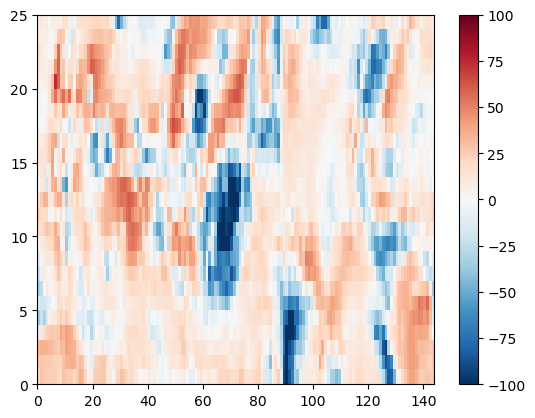

In [107]:
plt.pcolormesh(olr_anom_harmon_daily_ds[0, :, :], cmap='RdBu_r', vmax=100, vmin=-100)
plt.colorbar()

In [112]:
olr_anom_harmon_p_daily_da

<xarray.DataArray 'olr' (lat: 25, lon: 144, time: 16802)> Size: 242MB
dask.array<transpose, shape=(25, 144, 16802), dtype=float32, chunksize=(25, 144, 16802), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 134kB 1979-01-01T12:00:00 ... 2024-12-31T1...

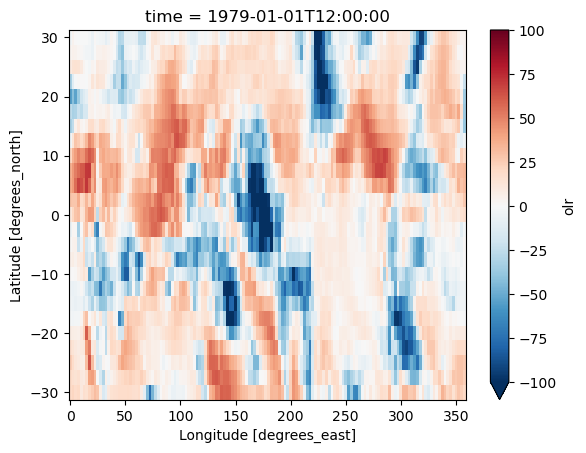

In [113]:
olr_anom_harmon_p_daily_da.isel(time=0).plot(cmap='RdBu_r', vmax=100, vmin=-100)

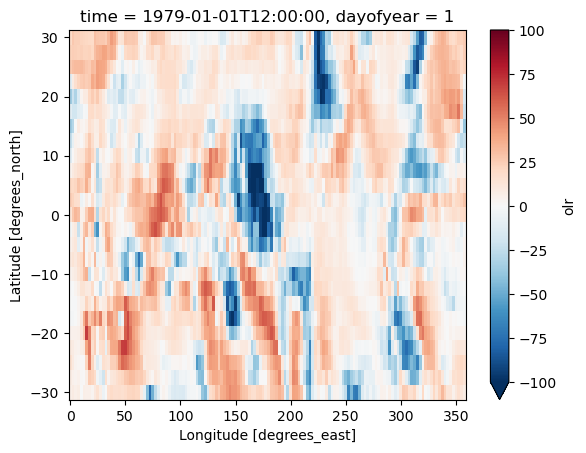

In [110]:
olr_anom_daily_ds.olr.isel(time=0).plot(cmap='RdBu_r', vmax=100, vmin=-100)

In [119]:
olr_anom_harmon_p_daily_da = olr_anom_harmon_p_daily_da.transpose(*(olr_anom_harmon_p_daily_da.dims[-1],) + olr_anom_harmon_p_daily_da.dims[:-1])

### Zonal Wind

In [6]:
uwind_ncep_ncar_store = s3fs.S3Map(
    root=f'pythia/uwind-ncep-ncar.zarr',
    s3=fs,
    check=False
)

# Open with xarray
uwind_daily_ds = xr.open_zarr(uwind_ncep_ncar_store)
uwind_daily_ds

<xarray.Dataset> Size: 495MB
Dimensions:  (lat: 25, level: 2, lon: 144, time: 17167)
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * level    (level) float32 8B 850.0 200.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    uwnd     (time, level, lat, lon) float32 494MB dask.array<chunksize=(1024, 2, 25, 144), meta=np.ndarray>

In [30]:
uwind_daily_ds

<xarray.Dataset> Size: 495MB
Dimensions:  (lat: 25, level: 2, lon: 144, time: 17167)
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * level    (level) float32 8B 850.0 200.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    uwnd     (time, level, lat, lon) float32 494MB dask.array<chunksize=(1024, 2, 25, 144), meta=np.ndarray>

In [31]:
uwind_nairobi = uwind_daily_ds.sel(NAIROBI_COORDS, method='nearest').sel(level=850)

In [32]:
uwind_nairobi = uwind_nairobi.chunk(dict(time=-1))

uwind_nairobi = uwind_nairobi.interpolate_na(dim='time', method='linear')


## Alignment

In [33]:
# Floor the time coordinates to the day
uwind_daily_ds['time'] = uwind_daily_ds.time.dt.floor('D')
olr_daily_ds['time'] = olr_daily_ds.time.dt.floor('D')

# Shift the OLR data by the lead time
olr_shifted = olr_daily_ds.shift(time=LEAD_TIME)

# Align the two datasets
uwind_aligned, olr_aligned = xr.align(uwind_nairobi, olr_shifted, join="inner")

# Create the predictor (X) and target (y) variables
X = olr_aligned["olr"].compute()
y = uwind_aligned["uwnd"].compute()

print("Shape of predictor (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of predictor (X): (16802, 25, 144)
Shape of target (y): (16802,)


## Train-Test Split

In [60]:
# Split data into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=false, test_size=0.2, random_state=42)

NameError: name 'false' is not defined

In [35]:
# Calculate the daily climatology
climatology = X_train.groupby('time.dayofyear').mean('time')

# Calculate the anomalies by subtracting the climatology
X_train = X_train.groupby('time.dayofyear') - climatology

X_test = X_test.groupby('time.dayofyear') - climatology

In [36]:
X_train.shape

(13441, 25, 144)

In [55]:
# Convert xarray DataArrays to plain NumPy arrays and flatten spatial dimensions
# Shape goes from (time, lat, lon) to (time, lat * lon)
X_train_flat = X_train.values.reshape(X_train.shape[0], -1)
X_test_flat = X_test.values.reshape(X_test.shape[0], -1)

# Extract NumPy arrays for your targets as well
y_train_np = y_train.values
y_test_np = y_test.values

print(f"Flattened X_train shape: {X_train_flat.shape}")
print(f"Flattened y_train shape: {y_train_np.shape}")

Flattened X_train shape: (13441, 3600)
Flattened y_train shape: (13441,)


### Modelling


In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification


In [59]:
# Scale features to have a mean of 0 and standard deviation of 1
# scaler = StandardScaler()
# X_train_flat = scaler.fit_transform(X_train_flat)
# X_test_flat = scaler.transform(X_test_flat)

# 2. Build the ANN Model with Fixed Hyperparameters
model = Sequential([
    Input(shape=(X_train_flat.shape[1],)), # Input Layer
    Dense(32, activation='relu'), # Hidden Layer 1: 32 neurons
    Dense(16, activation='relu'), # Hidden Layer 2: 16 neurons
    Dense(1, activation='linear') # Output Layer for regression
])

# 3. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 4. Train the Model (Fitting data with fixed hyperparameters)
history = model.fit(
    X_train_flat, y_train_np,
    epochs=50, # Fixed number of epochs
    batch_size=32, # Fixed batch size
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1 # Output training logs to console
)

# 5. Evaluate the Model on unseen test data
test_loss, test_mae = model.evaluate(X_test_flat, y_test_np)
print(f"Test MAE: {test_mae:.4f}")

Epoch 1/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/50
331/336 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - mae: nan

KeyboardInterrupt: 

### Another content subsection
Keep up the good work! A note, *try to avoid using code comments as narrative*, and instead let them only exist as brief clarifications where necessary.

## Your second content section
Here we can move on to our second objective, and we can demonstrate...

### A subsection to the second section

#### a quick demonstration

##### of further and further

###### header levels

as well as $m = a * t / h$ text! Similarly, you have access to other $\LaTeX$ equation [**functionality**](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Typesetting%20Equations.html) via MathJax:

\begin{align}
\dot{x} & = \sigma(y-x) \\
\dot{y} & = \rho x - y - xz \\
\dot{z} & = -\beta z + xy
\end{align}

Check out [**any number of helpful Markdown resources**](https://www.markdownguide.org/basic-syntax/) for further customizing your notebooks and the [**MyST Syntax Overview**](https://mystmd.org/guide/syntax-overview) for MyST-specific formatting information. Don't hesitate to ask questions if you have problems getting it to look *just right*.

## Last Section

You can add [admonitions using MyST syntax](https://mystmd.org/guide/admonitions):

:::{note}
Your relevant information here!
:::

Some other admonitions you can put in ([there are 10 total](https://mystmd.org/guide/admonitions#admonitions-list)):

:::{hint}
A helpful hint.
:::

:::{warning}
Be careful!
:::

:::{danger}
Scary stuff be here.
:::

We also suggest checking out MyST's [brief demonstration](https://mystmd.org/guide/notebook-configuration#notebook-cell-tags) on adding cell tags to your cells in Jupyter Notebook, Lab, or manually. See [this table](https://mystmd.org/guide/notebook-configuration#tbl-notebook-cell-tags) for a list of supported cell tags, which you can use to customize how your code content is displayed and even [demonstrate errors](https://mystmd.org/guide/execute-notebooks#allow-a-code-cell-to-error-without-failing-the-build) without altogether crashing our loyal army of machines!

---

## Summary
Add one final `---` marking the end of your body of content, and then conclude with a brief single paragraph summarizing at a high level the key pieces that were learned and how they tied to your objectives. Look to reiterate what the most important takeaways were.

### What's next?
Let Jupyter book tie this to the next (sequential) piece of content that people could move on to down below and in the sidebar. However, if this page uniquely enables your reader to tackle other nonsequential concepts throughout this book, or even external content, link to it here!

## Resources and references
Finally, be rigorous in your citations and references as necessary. Give credit where credit is due. Also, feel free to link to relevant external material, further reading, documentation, etc. Then you're done! Give yourself a quick review, a high five, and send us a pull request. A few final notes:
 - `Kernel > Restart Kernel and Run All Cells...` to confirm that your notebook will cleanly run from start to finish
 - `Kernel > Restart Kernel and Clear All Outputs...` before committing your notebook, our machines will do the heavy lifting
 - Take credit! Provide author contact information if you'd like; if so, consider adding information here at the bottom of your notebook
 - Give credit! Attribute appropriate authorship for referenced code, information, images, etc.
 - Only include what you're legally allowed: **no copyright infringement or plagiarism**
 
Thank you for your contribution!